In [1]:
%load_ext autoreload
%autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData
from redoxed.dc import PolarisationData


from schemdraw import Drawing

from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)

from IPython.display import Markdown


# %load_ext autoreload
# %autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots.eis_plot import NyquistPlot
from redoxed.plots.drt_plot import DRTPlot
from redoxed.plots import ResidualsPlot
from redoxed.impedance import EISData, DRTData
from redoxed import config
config.set_latex_mode(False)  # Set to True if you want LaTeX rendering in plots

from IPython.display import Markdown

import pyDRTtools



%matplotlib inline

Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

In [3]:

from pyimpspec.analysis.drt.peak_analysis import (
    DRTPeaks,
    _analyze_peaks,
)

def peak_analysis(DRTData_object, num_peaks, peak_positions, disallow_skew):
    time_constants = DRTData_object.tau
    gammas = DRTData_object.gamma
    DRTPeaks_object = _analyze_peaks(
        time_constants, gammas, num_peaks, peak_positions, disallow_skew
    )
    return DRTPeaks_object

# DRT_peak_fit_total = DRTData(tau = DRTPeaks_object.get_time_constants(), gamma = DRTPeaks_object.get_gammas(), label = "Peak fit")
# DRTPeaks_object.peaks[0].get_gammas(time_constants=DRTPeaks_object.get_time_constants())
# df = DRTPeaks_object.to_peaks_dataframe()

import numpy as np

def H_N_Z(f, Z0, tau0, alpha=1, beta=1):
    """
    Havriliak-Negami
    Alpha controls broadening of the spectra, beta controls the asymmetry of the spectra.
    With beta = 1, the H-N function reduces to a ZARC, with alpha=beta=1, it reduces to an RC
    This function is a placeholder for the H-N function.
    It currently does not perform any operations or return any values.
    """
    return Z0*(1+(1j*2*np.pi*f*tau0)**alpha)**(-beta)

def H_N_DRT(tau, Z0, tau0, alpha, beta):
    """
    Havriliak-Negami
    This function is a placeholder for the H-N function.
    It currently does not perform any operations or return any values.
    """
    theta = np.arctan(np.abs((np.sin(np.pi*alpha))/(((tau/tau0)**alpha)+np.cos(np.pi*alpha))))
    return (Z0/np.pi)*((tau/tau0)**(alpha*beta))*np.sin(beta*theta)*(1+((tau/tau0)**(2*alpha))+(2*(tau/tau0)**(alpha))*(np.cos(np.pi*alpha)))**(-beta/2)


import datetime

def ole_to_seconds(ole_timestamp):
    # OLE base date is 1899-12-30
    ole_base = datetime.datetime(1899, 12, 30)
    dt = ole_base + datetime.timedelta(days=ole_timestamp)
    # Convert to seconds since Unix epoch
    unix_epoch = datetime.datetime(1970, 1, 1)
    seconds = (dt - unix_epoch).total_seconds()
    return seconds


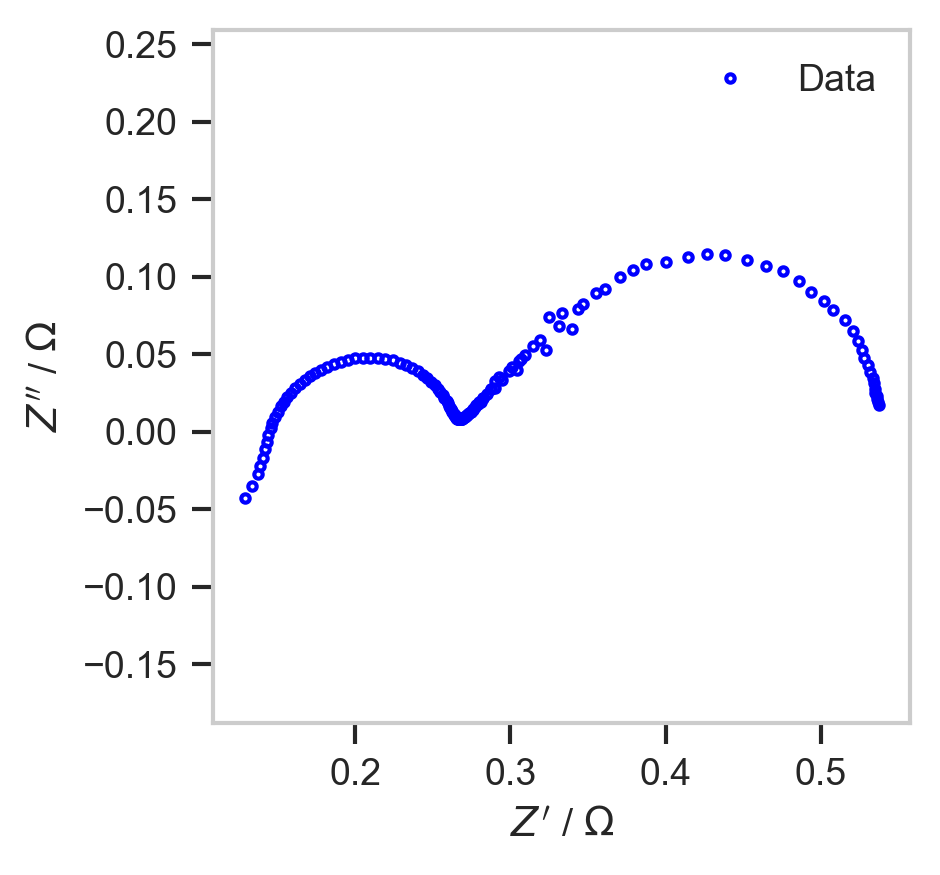

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-05
     pcost       dcost       gap    pres   dres
 0: -1.4531e+01 -1.6532e+01  2e+02  1e+01  1e-04
 1: -1.3959e+01 -1.7350e+01  2e+01  2e+00  1e-05
 2: -1.4250e+01 -1.6289e+01  2e+00  2e-02  1e-07
 3: -1.4411e+01 -1.5145e+01  8e-01  5e-03  4e-08
 4: -1.4474e+01 -1.4978e+01  5e-01  1e-03  1e-08
 5: -1.4518e+01 -1.4601e+01  8e-02  2e-04  1e-09
 6: -1.4533e+01 -1.4554e+01  2e-02  9e-07  8e-12
 7: -1.4535e+01 -1.4539e+01  4e-03  1e-07  1e-12
 8: -1.4536e+01 -1.4537e+01  8e-04  7e-17  6e-16
 9: -1.4536e+01 -1.4536e+01  2e-04  1e-16  8e-16
10: -1.4536e+01 -1.4536e+01  6e-05  7e-17  1e-15
11: -1.4536e+01 -1.4536e+01  8e-06  1e-16  5e-16
Optimal solution found.
R = 0.1191152457046809, L = 4.9469224899737815e-08, lambda = 1e-05


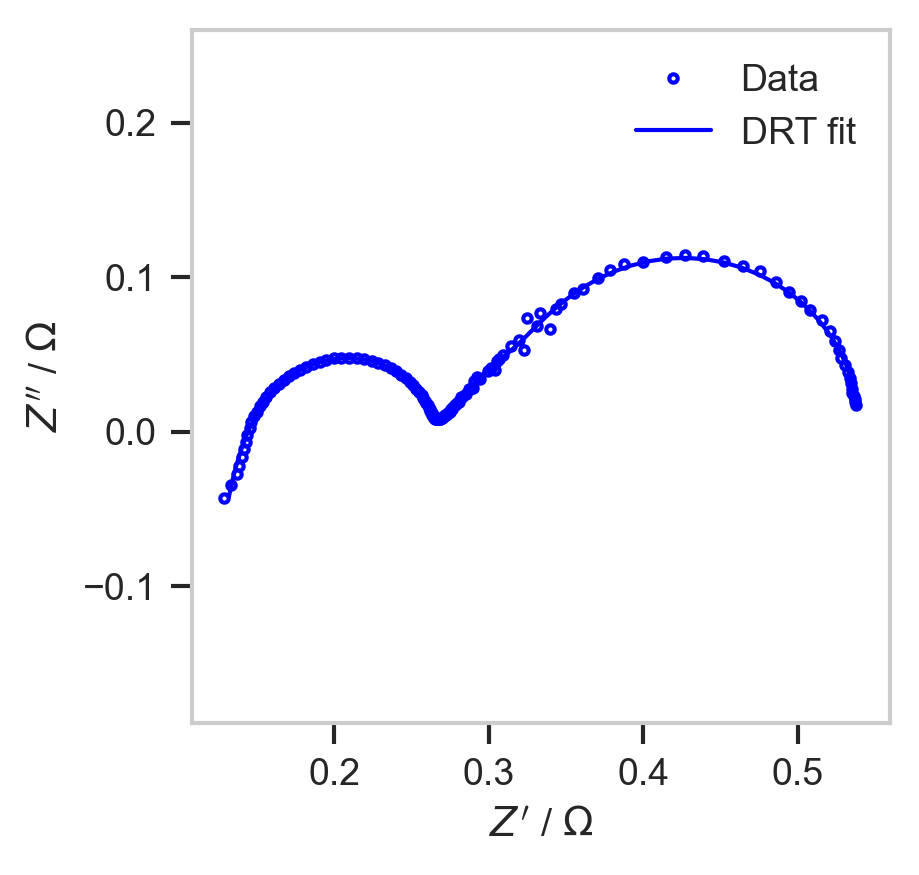

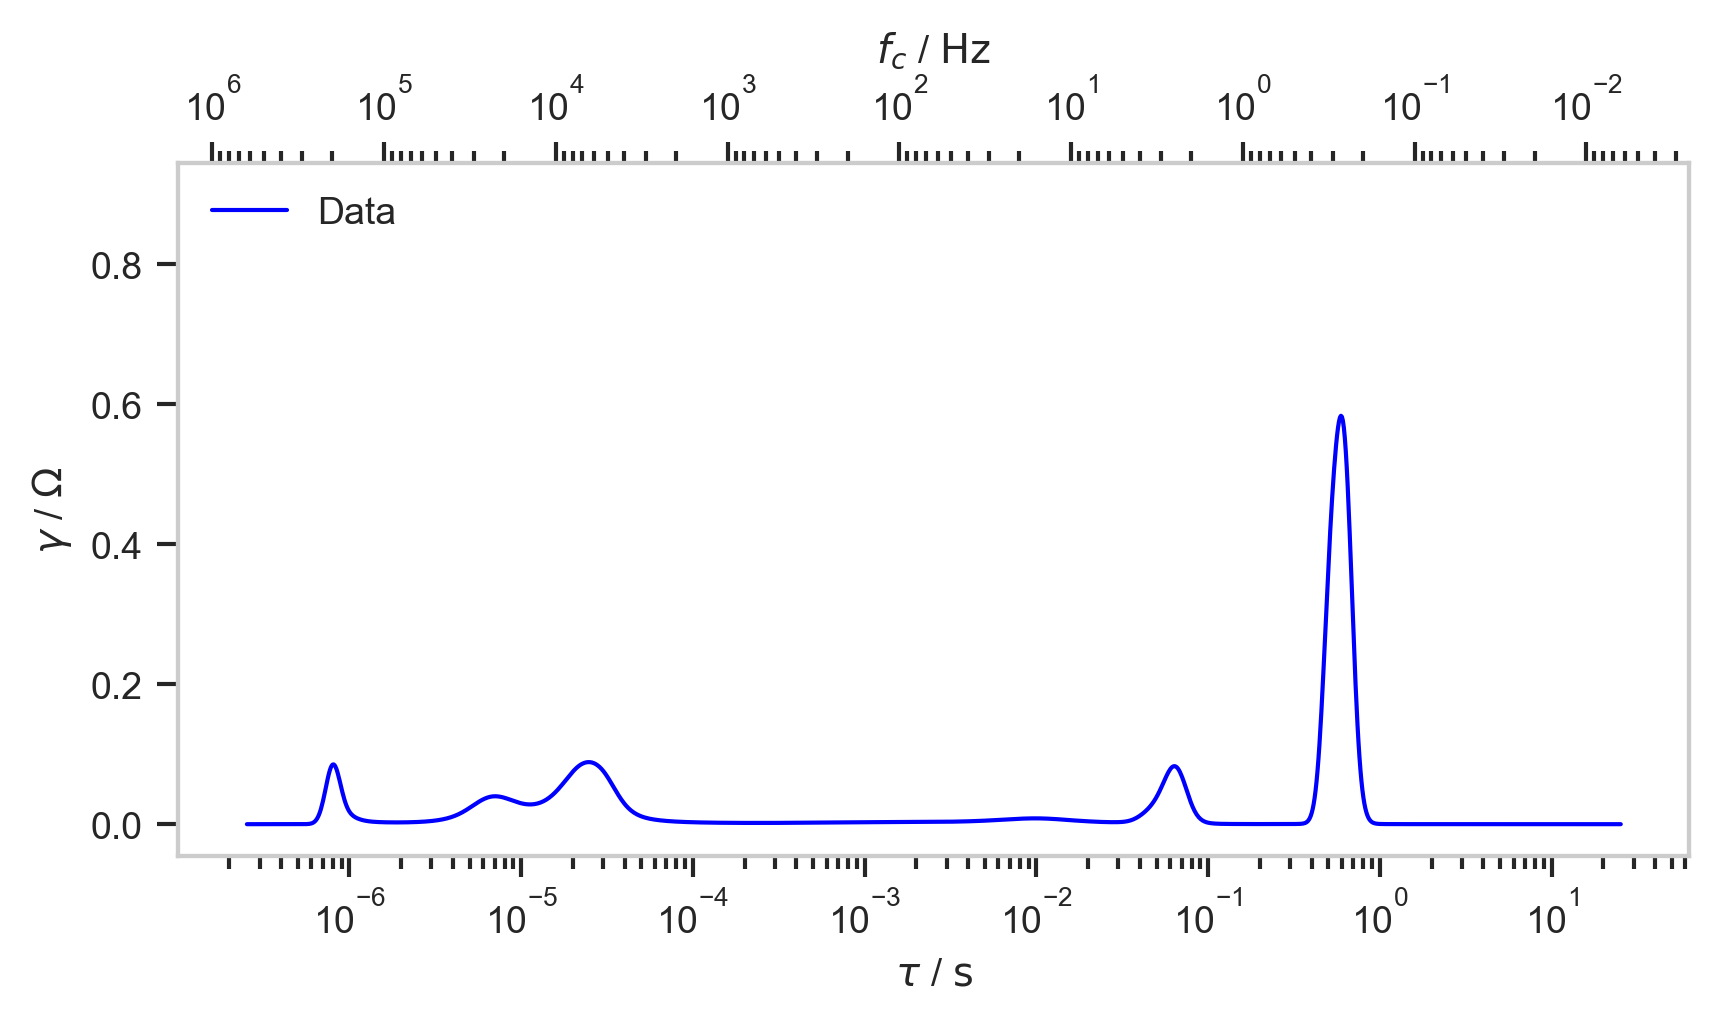

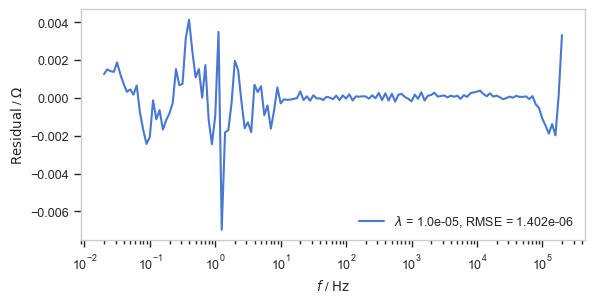

In [21]:
EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

lambda_0 = 1e-5

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\1_50ml_20mM_FCN_33rpm_03_GEIS_C04.mpr"
label = "Data"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
EISData_object = ECData_object.to_EISData()
EISData_object.label = label
EISData_array.append(EISData_object)

# Generate a color array using a colormap
num_colors = 10  # Number of colors needed
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))  # Use the 'viridis' colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_colors))  # Use the 'hsv' colormap
colors = ["blue",]


NyquistPlot_object = NyquistPlot(figsize=(3, 3), dpi=300) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    #EISData_object.crop_frequency(1, 8e3)
    EISData_object.crop_frequency(0.01, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 2, markerfacecolor = 'none', markeredgecolor = colors[i], zorder = 3)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.05)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
NyquistPlot_object.ax.legend()

# 0 point
#NyquistPlot_object.ax.plot(0, -0.05, marker = "", linestyle = "")
#NyquistPlot_object.ax.plot(0.7, 0.2, marker = "", linestyle = "")

display(NyquistPlot_object.fig)



DRTPlot_object = DRTPlot(figsize=(6.5, 3), dpi=300) 

ResidualsPlot_object = ResidualsPlot(figsize=(6.5, 3), dpi=100)

for i, EISData_object in enumerate(EISData_array):
    # Load measurement data into EIS_object
    pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
    # this includes tau definition of
    # # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
    # # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0]
    
    lambda_0 = lambda_0 # initial guess

    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda

    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    f_pyDRTtools = fitted_entry.freq
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    res_re_pyDRTtools = fitted_entry.res_re # absolute difference between the real part of the measured and fitted data
    rmse_res_re_pyDRTtools = np.sum(res_re_pyDRTtools**2)/len(res_re_pyDRTtools) # root mean square error of the real part of the impedance
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "DRT fit")

    fitted_EISData_array.append(EISData_fitted_pyDRTtools)
    DRTData_array.append(DRT_object_pyDRTtools)
    R_array.append(R_pyDRTtools)
    L_array.append(L_pyDRTtools)

    print(f"R = {R_pyDRTtools}, L = {L_pyDRTtools}, lambda = {lambda_value_pyDRTtools}")

    NyquistPlot_object.add_plot(EISData_fitted_pyDRTtools, linestyle = "-", marker = "", linewidth = 1, color = colors[i])

    
    DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", color = colors[i], linewidth =1)

    
    ResidualsPlot_object.add_plot(f=f_pyDRTtools, 
                    residual = res_re_pyDRTtools, 
                    linestyle = "-", 
                    marker = "", 
                    #label = "$\lambda$ = " + str(lambda_value_pyDRTtools)+", RMSE = " + str(rmse_res_re_pyDRTtools)) 
                    label=f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}, RMSE = {rmse_res_re_pyDRTtools:.3e}"
    )  


    # print(res_re_pyDRTtools)
    # print(Z_pyDRTtools.real)
    # print(EISData_object.Z.real)
NyquistPlot_object.add_major_ticks(spacing_x = 0.1, spacing_y=0.1)
NyquistPlot_object.ax.legend()
display(NyquistPlot_object.fig)


### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
## Embellishments
# data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
DRTPlot_object.ax.legend()

DRTPlot_object.add_fc_axis()
DRTPlot_object.ax.plot(1e1, 0.9, marker = "", linestyle = "")
display(DRTPlot_object.fig)

ResidualsPlot_object.ax.legend()

display(ResidualsPlot_object.fig)

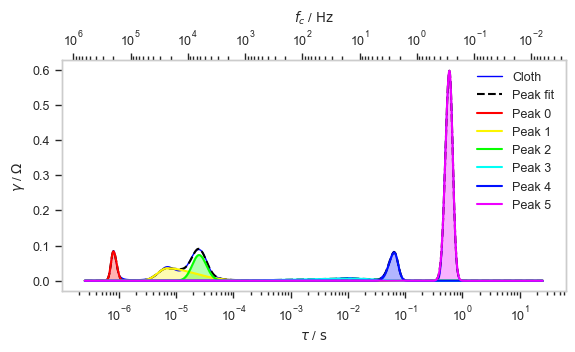

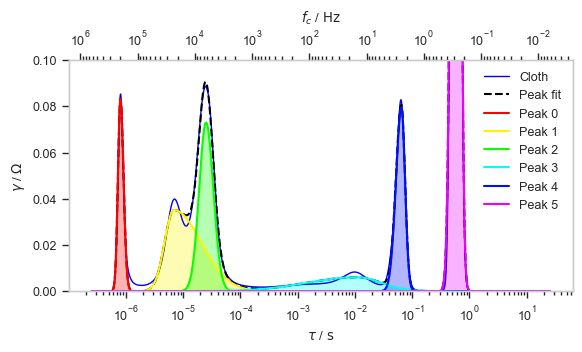

        tau (s)  gamma (ohm)  R_peak (ohm)
0  7.998357e-07     0.083349      0.023287
1  6.854434e-06     0.035180      0.064342
2  2.505726e-05     0.073030      0.052186
3  1.085781e-02     0.006067      0.022691
4  6.480977e-02     0.079610      0.036374
5  5.920152e-01     0.596809      0.220819
0.1191152457046809
4.9469224899737815e-08
Ohmic: 0.14240264257483956
Activation: 0.11652837862856166
Concentration: 0.279883574050644


In [4]:
DRTPeaks_object = peak_analysis(DRTData_array[0], num_peaks = 6, peak_positions = None, disallow_skew=False) #, peak_positions = [1e-5, 1e-4, 1e-3], disallow_skew = False)
df = DRTPeaks_object.to_peaks_dataframe()

DRT_peak_fit_total = DRTData(tau = DRTPeaks_object.get_time_constants(), gamma = DRTPeaks_object.get_gammas(), label = "Peak fit")
# DRTPeaks_object.peaks[0].get_gammas(time_constants=DRTPeaks_object.get_time_constants())
# 

DRTPlot_object = DRTPlot(figsize=(6.5, 3), dpi=100)
DRTPlot_object.add_plot(DRTData_array[0], linestyle = "-", marker = "", color = "blue", linewidth = 1 )#, zorder=3) 

# for i, DRT_object_pyDRTtools in enumerate(DRTData_array):
#     DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", color = colors[i])

DRTPlot_object.add_plot(DRT_peak_fit_total, linestyle = "--", marker = "", color = "black")


# Generate a color array using a colormap
num_colors = 7  # Number of colors needed
# colors = plt.cm.viridis(np.linspace(0, 1, num_colors))  # Use the 'viridis' colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_colors))  # Use the 'hsv' colormap

for i, peak in enumerate(DRTPeaks_object.peaks):
    #print(peak)
    #print(peak.get_area(DRT_peak_fit_total.tau))
    DRTData_object = DRTData(tau = DRT_peak_fit_total.tau, gamma = peak.get_gammas(time_constants=DRT_peak_fit_total.tau), label = f"Peak {i}")
    DRTPlot_object.add_plot(DRTData_object, linestyle = "-", marker = "", color = colors[i])
    DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), color=colors[i], alpha=0.3)


DRTPlot_object.ax.legend()
DRTPlot_object.add_fc_axis()
display(DRTPlot_object.fig)

DRTPlot_object.ax.set_ylim([0, 0.1])
display(DRTPlot_object.fig)

print(df)
print(R_array[0])
print(L_array[0])

peak_Z_array = df["R_peak (ohm)"].to_numpy()
Z_ohm = R_array[0] + peak_Z_array[0]
Z_act = peak_Z_array[1] + peak_Z_array[2]
Z_conc = peak_Z_array[3] + peak_Z_array[4] + peak_Z_array[5]
Z_list = [Z_ohm, Z_act, Z_conc]
labels = ['Ohmic', 'Activation', 'Concentration']
color_list = ['cyan', 'yellow', 'indigo']

for i in range(len(Z_list)):
    print(f"{labels[i]}: {Z_list[i]}")



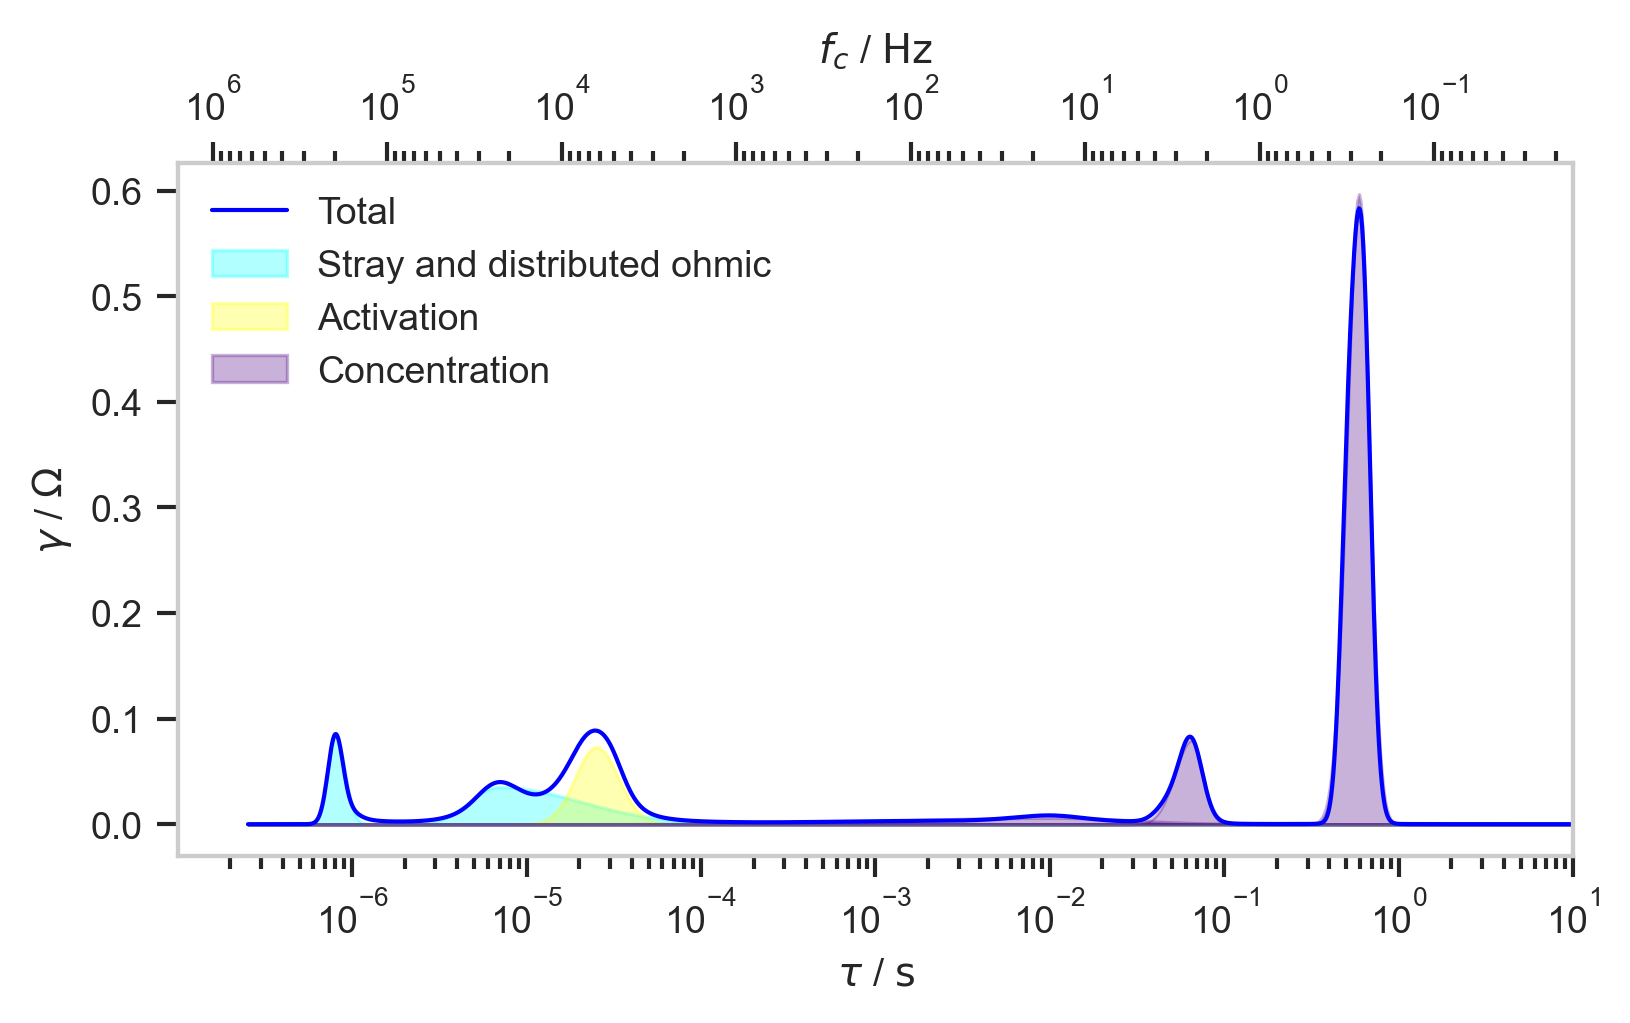

In [15]:
DRTPeaks_object = peak_analysis(DRTData_array[0], num_peaks = 6, peak_positions = None, disallow_skew=False) #, peak_positions = [1e-5, 1e-4, 1e-3], disallow_skew = False)
df = DRTPeaks_object.to_peaks_dataframe()

DRT_peak_fit_total = DRTData(tau = DRTPeaks_object.get_time_constants(), gamma = DRTPeaks_object.get_gammas(), label = "Peak fit")
# DRTPeaks_object.peaks[0].get_gammas(time_constants=DRTPeaks_object.get_time_constants())
# 

DRTPlot_object = DRTPlot(figsize=(6, 3), dpi=300)
DRTPlot_object.add_plot(DRTData_array[0], linestyle = "-", marker = "", color = "blue", linewidth = 1, label = "Total")#, zorder=3) 

# for i, DRT_object_pyDRTtools in enumerate(DRTData_array):
#     DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", color = colors[i])

# DRTPlot_object.add_plot(DRT_peak_fit_total, linestyle = "--", marker = "", color = "black")


# Generate a color array using a colormap
num_colors = 7  # Number of colors needed
# colors = plt.cm.viridis(np.linspace(0, 1, num_colors))  # Use the 'viridis' colormap
colors = plt.cm.hsv(np.linspace(0, 1, num_colors))  # Use the 'hsv' colormap
colors = color_list

tau = DRT_peak_fit_total.tau

# ohmic
i =0
gamma = DRTPeaks_object.peaks[0].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = "Stray and distributed ohmic")
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), label = "Stray and distributed ohmic", color=colors[i], alpha=0.3)

gamma = DRTPeaks_object.peaks[1].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = None)
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), color=colors[i], alpha=0.3)

# activation
i=1
gamma = DRTPeaks_object.peaks[2].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = "Activation")
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), label = 'Activation', color=colors[i], alpha=0.3)

# concentration
i=2
gamma = DRTPeaks_object.peaks[3].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = "Concentration")
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), label = "Concentration", color=colors[i], alpha=0.3)
gamma = DRTPeaks_object.peaks[4].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = None)
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), color=colors[i], alpha=0.3)
gamma = DRTPeaks_object.peaks[5].get_gammas(time_constants=tau)
DRTData_object = DRTData(tau = tau, gamma = gamma, label = None)
DRTPlot_object.ax.fill_between(DRTData_object.tau, DRTData_object.gamma, 0, where=(DRTData_object.gamma >= 0), color=colors[i], alpha=0.3)


DRTPlot_object.ax.legend(loc="upper left")
DRTPlot_object.ax.plot(1e1, 0.5, marker = "", linestyle = "")

DRTPlot_object.ax.set_xlim([None, 1e1])
DRTPlot_object.add_fc_axis()
display(DRTPlot_object.fig)